# Visualise Coarse-Grained results of the Bedload Transport example

### Import relevant packages

In [1]:
from pysammos.data_write.h5.writer import H5XarrayManager
from pysammos.post_averaging.profiles import VerticalIntegrator

Hello from pysammos
Loading data_write package...
Loading post_averaging package...


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import pyvista as pv
from matplotlib.lines import Line2D
import matplotlib as mpl

In [3]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams.update({'font.size': 16})
# axis labels and legend in 16 
matplotlib.rcParams.update({'axes.labelsize': 18})
matplotlib.rcParams.update({'legend.fontsize': 18})

### Initialise data reader manager

In [4]:
manager = H5XarrayManager("../data_examples/erodible_bed/Pysammos_data_paper/CG_Lucy_Monodisperse.h5")
erosion_CG = manager.h5_to_xarray()

Processing key: density_mixture
Processing key: frictional_coefficient_01_Pxy
Processing key: frictional_coefficient_01_Pxyz
Processing key: frictional_coefficient_01_Py
Processing key: frictional_coefficient_Dxy_Pxy
Processing key: frictional_coefficient_Dxy_Pxyz
Processing key: frictional_coefficient_Dxy_Py
Processing key: frictional_coefficient_Dxyz_Pxy
Processing key: frictional_coefficient_Dxyz_Pxyz
Processing key: frictional_coefficient_Dxyz_Py
Processing key: granular_temperature_x
Processing key: granular_temperature_xyz
Processing key: granular_temperature_y
Processing key: granular_temperature_z
Processing key: inertial_number_Sxy_Pxy_d32
Processing key: inertial_number_Sxy_Pxy_d43
Processing key: inertial_number_Sxy_Pxyz_d32
Processing key: inertial_number_Sxy_Pxyz_d43
Processing key: inertial_number_Sxy_Py_d32
Processing key: inertial_number_Sxy_Py_d43
Processing key: positions
Processing key: pressure_x
Processing key: pressure_xy
Processing key: pressure_xyz
Processing ke

### Data format inspection

In [5]:
erosion_CG.positions

<xarray.DataArray 'positions' (point: 36075, xyz: 3)> Size: 866kB
array([[0.005  , 0.005  , 0.005  ],
       [0.005  , 0.005  , 0.00875],
       [0.005  , 0.005  , 0.0125 ],
       ...,
       [0.1    , 0.44   , 0.0425 ],
       [0.1    , 0.44   , 0.04625],
       [0.1    , 0.44   , 0.05   ]])
Coordinates:
  * point      (point) int64 289kB 0 1 2 3 4 5 ... 36070 36071 36072 36073 36074
    positions  (point, xyz) float64 866kB 0.005 0.005 0.005 ... 0.1 0.44 0.05
Dimensions without coordinates: xyz

In [6]:
erosion_CG.time

<xarray.DataArray 'time' (time: 145)> Size: 1kB
array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
        85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
       141, 142, 143, 144, 145])
Coordinates:
  * time     (time) int64 1kB 1 2 3 4 5 6 7 8 ... 139 140 141 142 143 144 145

### Granular temperature in slices

In [7]:
# initialise data reader manager
manager_gt = H5XarrayManager("../data_examples/erodible_bed/Pysammos_data_paper/CG_GranularTemperature_slices.h5")
slices_gt = manager_gt.h5_to_xarray()

Processing key: granular_temperature_Kamrin
Processing key: granular_temperature_LAMMPS
Processing key: positions
Processing key: time


In [8]:
# Perform vertical integration
VI = VerticalIntegrator(erosion_CG, 'y')
vertical_ds_general = VI.integration()

Starting integration along profile dimension: y
Completed integration along profile dimension: y


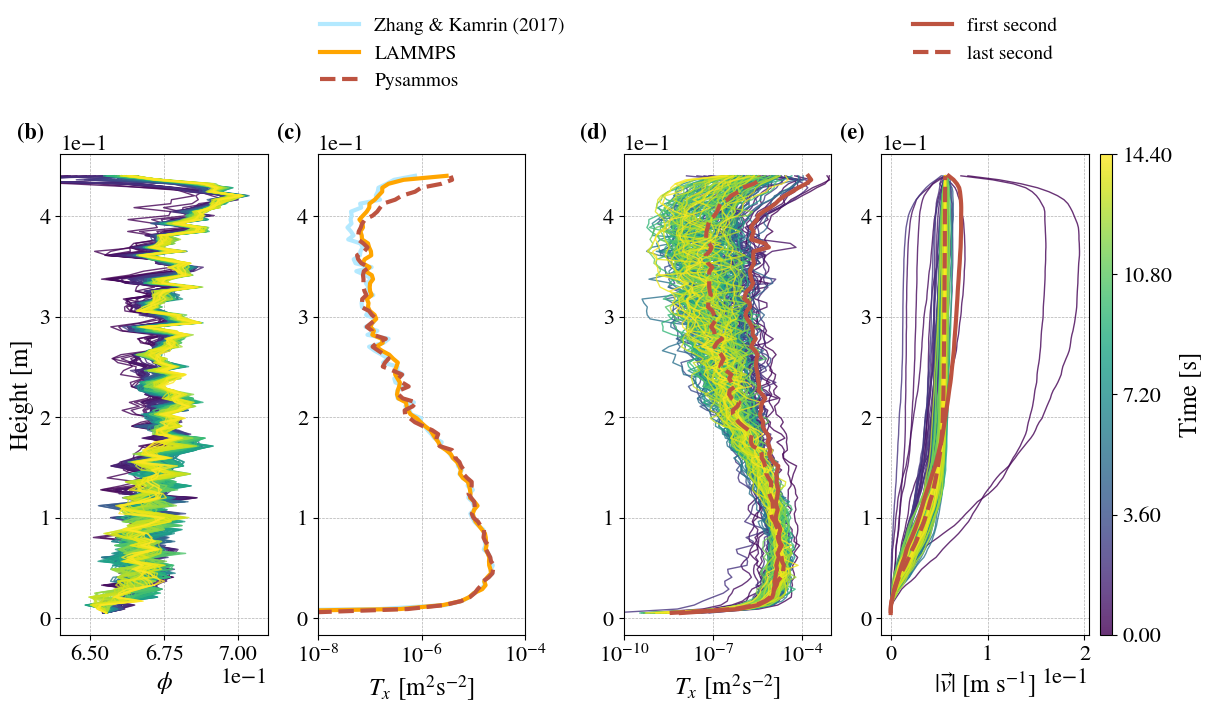

In [9]:
fig, ax = plt.subplots(1,4, figsize=(12,7), constrained_layout=True)

num_timesteps = 145

cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=num_timesteps - 1)
colors = [cmap(norm(i)) for i in range(num_timesteps)]

# ======================================================================= # 
ti_10 = 10

# 0) VOLUME FRACTION
for i in range(num_timesteps):
    ax[0].plot(vertical_ds_general['volume_fraction'].isel(time=i), vertical_ds_general['y'].values, color=colors[i], alpha = 0.8, lw=1)


# 1) GRANULAR TEMPERATURE 
ax[1].plot(slices_gt.granular_temperature_Kamrin[-ti_10:-1,:,0].mean(axis=0), slices_gt.positions[:, 1], color='#B3E9FF', lw=3, ls='-', label='Zhang & Kamrin (2017)') # delta t = 1s (last)
ax[1].plot(slices_gt.granular_temperature_LAMMPS[-ti_10:-1,:,0].mean(axis=0), slices_gt.positions[:, 1], color='orange', linestyle='-', lw=3, label='LAMMPS') # delta t = 1s (last)
gt_last = vertical_ds_general['granular_temperature_x'].isel(time=slice(-ti_10, None))
gt_first = vertical_ds_general['granular_temperature_x'].isel(time=slice(0,ti_10))
ax[1].plot(np.mean(gt_last.values, axis=1),gt_last['y'].values, color='#BD5340', linestyle='--', lw=3, label='Pysammos')

# 2) GRANULAR TEMPERATURE
for i in range(num_timesteps):
    ax[2].plot(vertical_ds_general['granular_temperature_x'].isel(time=i), gt_last['y'].values, color=colors[i], alpha = 0.8, lw=1)
# plot the time average 
ax[2].plot(np.mean(gt_first.values, axis=1),gt_first['y'].values, color='#BD5340', linestyle='-', lw=3, label='first second') # first 1s
ax[2].plot(np.mean(gt_last.values, axis=1),gt_last['y'].values, color='#BD5340', linestyle='--', lw=3,label='last second') # last 1s


# 3) VELOCITY
for i in range(num_timesteps):
    v_x = vertical_ds_general['velocity'].isel(time=i, dim1_3D=0)
    v_y = vertical_ds_general['velocity'].isel(time=i, dim1_3D=1)
    v_z = vertical_ds_general['velocity'].isel(time=i, dim1_3D=2)
    vel_mag = np.sqrt(v_x**2 + v_y**2 + v_z**2)

    ax[3].plot(
        vel_mag.values,
        vel_mag['y'].values,
        color=cmap(norm(i)), alpha = 0.8, lw=1
    )

vel_last = vertical_ds_general['velocity'].isel(time=slice(-ti_10, None), dim1_3D=0)
vel_first = vertical_ds_general['velocity'].isel(time=slice(0,10), dim1_3D=0)
# plot the time average 
ax[3].plot(np.mean(vel_first.values, axis=1),vel_first['y'].values, color='#BD5340', linestyle='-', lw=3, label='first second') # first 1s
ax[3].plot(np.mean(vel_last.values, axis=1),vel_last['y'].values, color='#BD5340', linestyle='--', lw=3, label='last second') # last 1s

# ======================================================================= # 

# Create ScalarMappable for colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[3], fraction=0.8, pad=0.05, aspect=40, alpha=0.8 )
dt = 0.1
tick_locs = np.linspace(0, num_timesteps - 1, 5)
tick_labels = tick_locs * dt
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f"{t:.2f}" for t in tick_labels])
cbar.set_label('Time [s]')

# Set labels and title
for i in range(len(ax)):
    ax[i].ticklabel_format(axis='y', style='scientific', scilimits=(-1,1))
    ax[i].ticklabel_format(axis='x', style='scientific', scilimits=(-1,1))
    ax[i].grid(visible=True, which='both', linestyle='--', linewidth=0.5)
    ax[i].ticklabel_format(axis='both', style='scientific', scilimits=(-1,1))

ax[1].legend(fontsize=14, frameon=False, loc='upper center', bbox_to_anchor=(0.6, 1.32))
ax[3].legend(fontsize=14, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.32))
ax[0].set_ylabel('Height [m]')
ax[3].set_xlabel(r'$|\vec{v}|$ [m s$^{-1}$]')
ax[2].set_xlabel(r'$T_x$ [m$^2$s$^{-2}$]')
ax[1].set_xlabel(r'$T_x$ [m$^2$s$^{-2}$]')
ax[0].set_xlabel(r'$\phi$')
ax[1].set_xscale('log')
ax[2].set_xscale('log')
ax[2].set_xlim(1e-10, 1e-3)
ax[1].set_xlim(1e-8, 1e-4)
ax[0].set_xlim(0.64, 0.71)

# add grid to all the subplots
labels = ['(b)', '(c)', '(d)', '(e)']
for i in range(len(ax)): 
    axi = ax[i]
    axi.text(
        -0.08, 1.02, labels[i],
        transform=axi.transAxes,
        fontsize=16,
        fontweight='bold',
        va='bottom',
        ha='right'
    )

fig.savefig('/exports/csce/datastore/geos/users/s1857688/Paper_Writing/coarse_graining/erosion_profiles.png', dpi=600,
    bbox_inches='tight',
    pad_inches=0)
plt.show()
